#### Overall Summary

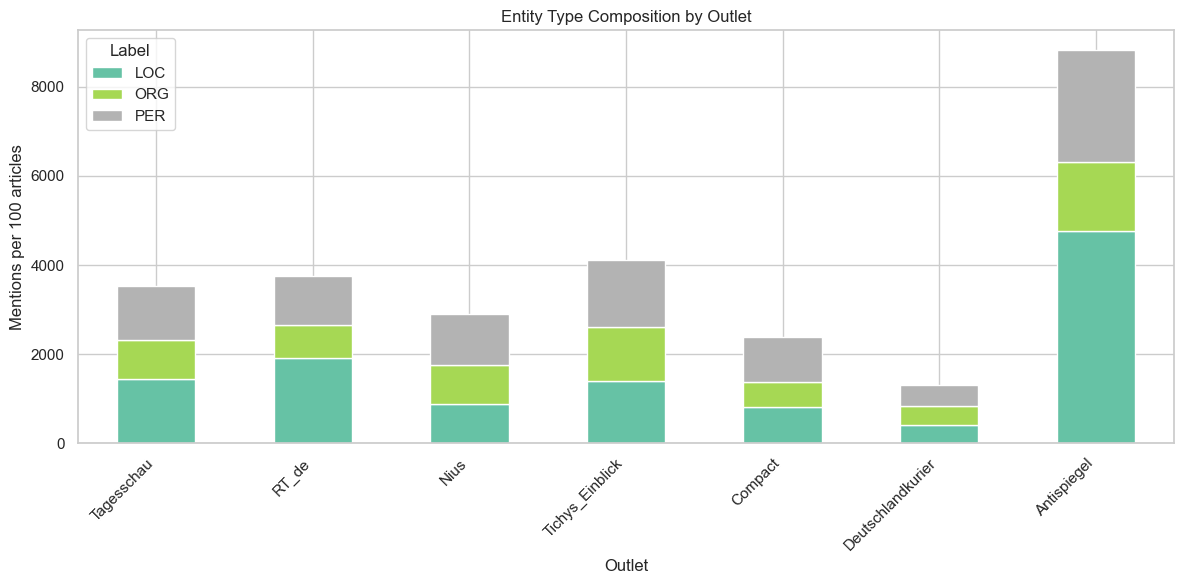

In [58]:
label_summary = (
    mentions.groupby(["source", "label"])
    .size()
    .rename("mentions")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

label_summary["mentions_per_100_articles"] = (
    label_summary["mentions"] / label_summary["n_articles"] * 100
)

plot_data = (
    label_summary.pivot(index="source", columns="label", values="mentions_per_100_articles")
    .fillna(0)
    .loc[outlet_order]
)

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Set2"
)
ax.set_title("Entity Type Composition by Outlet")
ax.set_xlabel("Outlet")
ax.set_ylabel("Mentions per 100 articles")
ax.legend(title="Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


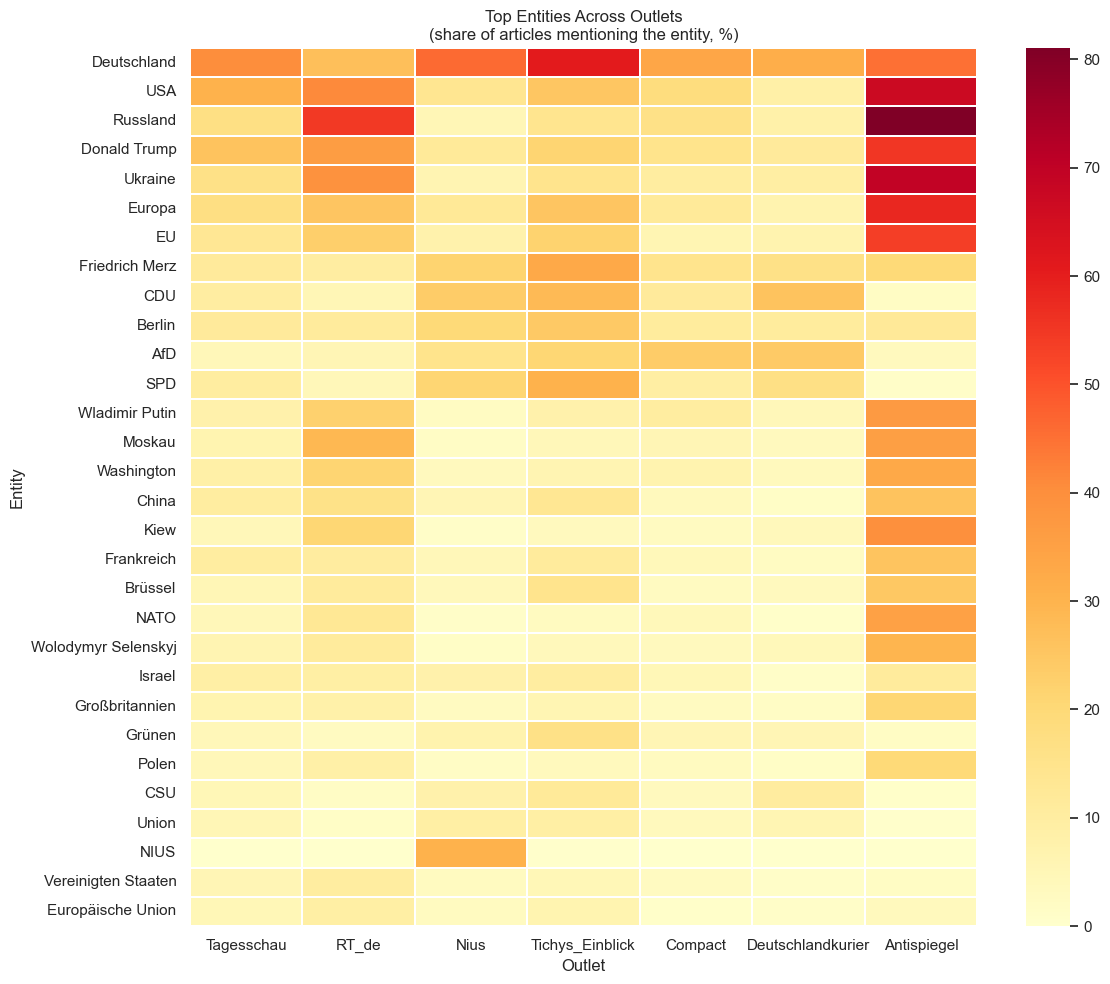

In [59]:
TOP_N = 30

top_global_entities = (
    mentions.groupby("entity")["row_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

heatmap_df = (
    mentions[mentions["entity"].isin(top_global_entities)]
    .groupby(["entity", "source"])["row_id"]
    .nunique()
    .rename("documents")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

heatmap_df["doc_share_pct"] = heatmap_df["documents"] / heatmap_df["n_articles"] * 100

heatmap_matrix = (
    heatmap_df.pivot(index="entity", columns="source", values="doc_share_pct")
    .fillna(0)
    .reindex(columns=outlet_order)
)

heatmap_matrix = heatmap_matrix.loc[
    heatmap_matrix.mean(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_matrix, cmap="YlOrRd", linewidths=0.3)
plt.title("Top Entities Across Outlets\n(share of articles mentioning the entity, %)")
plt.xlabel("Outlet")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()


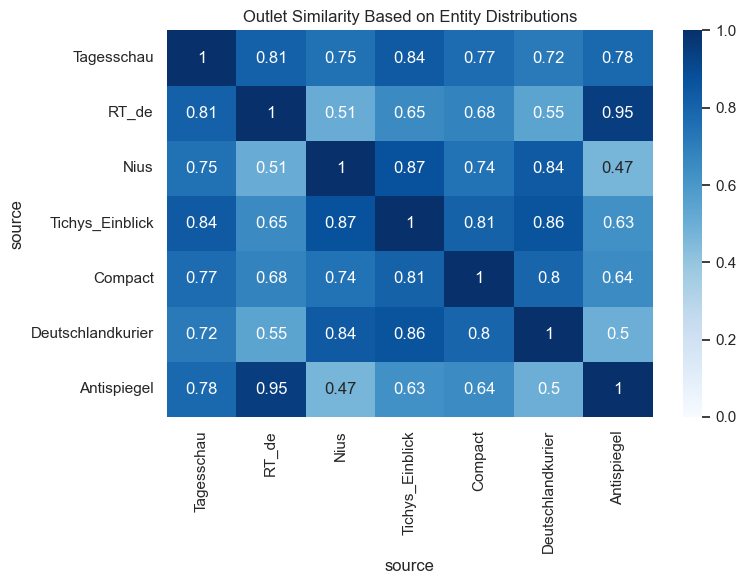

In [60]:
similarity_df = (
    mentions.groupby(["source", "entity"])["row_id"]
    .nunique()
    .rename("documents")
    .reset_index()
    .merge(articles_per_outlet.reset_index(), on="source", how="left")
)

similarity_df["doc_share"] = similarity_df["documents"] / similarity_df["n_articles"]

entity_matrix = (
    similarity_df.pivot(index="source", columns="entity", values="doc_share")
    .fillna(0)
    .reindex(outlet_order)
)

cosine_sim = pd.DataFrame(
    cosine_similarity(entity_matrix),
    index=entity_matrix.index,
    columns=entity_matrix.index,
)

plt.figure(figsize=(8, 6))
sns.heatmap(cosine_sim, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Outlet Similarity Based on Entity Distributions")
plt.tight_layout()
plt.show()


In [ ]:
import re
from pathlib import Path

import pandas as pd

# Load original dataframe if not already in memory
if "df" not in globals():
    df = pd.read_csv("/Users/katinkakurz/projects/Thesis/data/raw/df_combined.csv")

# Keep only the columns we need and drop Tagesschau rows
search_df = df[["row_id", "source", "Title", "Text"]].copy()
search_df = search_df[
    search_df["source"].fillna("").astype(str).str.casefold() != "tagesschau"
].copy()

# -----------------------------
# 1. REGEX PATTERNS
# -----------------------------
MEDIA_PATTERNS = [
    r"\bard\b",
    r"\bzdf\b",
    r"\b(?:der\s+)?spiegel\b",
    r"\btagesschau(?:\.de)?\b",
    r"\btagesschau24\b",
    r"\breuters\b",
    r"\bjan\s+böhmermann\b",
    r"\bndr(?:\s+info)?\b",
    r"\bnorddeutscher\s+rundfunk\b",
    r"\bbild-zeitung\b|\bdie\s+bild\b",
    r"\bpolitico\b",
    r"\bswr\b",
    r"\bsüdwestrundfunk\b",
    r"\bdpa\b",
    r"\bwdr\b",
    r"\bwestdeutscher\s+rundfunk\b",
    r"\bfaz\b",
    r"\bfrankfurter\s+allgemeine(?:n)?\s+zeitung\b",
    r"\börr\b",
    r"\bhandelsblatt\b",
    r"\bdeutschlandfunk\b",
    r"\btagesspiegel\b",
    r"\btaz\b",
    r"\bbr\b",
    r"\bbayerischer\s+rundfunk\b",
    r"\bberliner\s+zeitung\b",
    r"\brbb\b",
    r"\brundfunk\s+berlin-brandenburg\b",
    r"\bcorrectiv\b",
    r"\bsz\b",
    r"\bsüddeutsch(?:e|en)\s+zeitung\b",
    r"\bstern\b",
    r"\bdas\s+(?-i:Erste)\b"
    r"\bthe\s+european\b",
    r"\brtl\b",
    r"\bmdr\b",
    r"\bmitteldeutscher\s+rundfunk\b",
    r"\brnd\b",
    r"\bredaktionsnetzwerk\s+deutschland\b",
    r"\bcaren\s+miosga\b",
    r"\brheinisch(?:e|en)\s+post\b",
    #r"\bbund\b",
    r"\b(?:markus\s+)?lanz\b",
    #r"\bfocus\b",
    r"\beuronews\b",
]

# KEY CHANGE:
# "Medien" alone should NOT match.
# Only compounds like "Staatsmedien", "Leitmedien", "Altmedien" should match.
#KEYWORD_PATTERNS #= [
#     r"[a-zäöüß-]*presse[a-zäöüß-]*",
#     r"[a-zäöüß-]*funk[a-zäöüß-]*",
#     r"[a-zäöüß-]+(?:medien|medium|medial)[a-zäöüß-]*",
#     r"[a-zäöüß-]*sender[a-zäöüß-]*",
#     r"[a-zäöüß-]*öffentlich[a-zäöüß-]*[ -]?rechtlich[a-zäöüß-]*",
#     r"[a-zäöüß-]*fernseh[a-zäöüß-]*",
# ]

MASTER_PATTERN = re.compile(
    "|".join(f"(?:{p})" for p in MEDIA_PATTERNS),
    flags=re.IGNORECASE,
)

# -----------------------------
# 2. HELPER FUNCTIONS
# -----------------------------
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def combine_title_text(title, text):
    title = normalize_text(title)
    text = normalize_text(text)

    if title and text and not re.search(r"[.!?…:;]$", title):
        title = title + "."

    return f"{title} {text}".strip()

def split_sentences(text):
    text = normalize_text(text)
    if not text:
        return []

    sentences = re.split(r"(?<=[.!?…])\s+(?=[A-ZÄÖÜ0-9\"'“„(])", text)
    sentences = [s.strip() for s in sentences if s and s.strip()]
    return sentences

def extract_context_windows(text, pattern, window=1):
    sentences = split_sentences(text)
    if not sentences:
        return []

    matched_indices = [
        i for i, sentence in enumerate(sentences)
        if pattern.search(sentence)
    ]

    if not matched_indices:
        return []

    # Merge overlapping / immediately adjacent windows
    merged_windows = []
    for idx in matched_indices:
        start = max(0, idx - window)
        end = min(len(sentences), idx + window + 1)

        if merged_windows and start <= merged_windows[-1][1]:
            merged_windows[-1] = (merged_windows[-1][0], max(merged_windows[-1][1], end))
        else:
            merged_windows.append((start, end))

    return [" ".join(sentences[start:end]) for start, end in merged_windows]

# -----------------------------
# 3. BUILD SEARCH TEXT
# -----------------------------
search_df["combined_text"] = [
    combine_title_text(title, text)
    for title, text in zip(search_df["Title"], search_df["Text"])
]

candidate_df = search_df[
    search_df["combined_text"].str.contains(MASTER_PATTERN, na=False)
].copy()

# Add explicit ÖRR/media-related keywords (exact terms)
EXTRA_KEYWORDS = [
    "Mainstreammedien",
    "Staatsmedien",
    "Staatsfunk",
    "Qualitätsmedien",
    "Staatssender",
    "Lügenpresse",
    "Haltungsjournalisten",
    "Gleichschaltung",
    "Mainstreampresse",
    "Altmedien",
    "Systemmedien",
    "Qualitätsjournalismus",
    "Alternativmedien",
    "Gesternmedien",
    "Haltungsmedien",
    "Westmedien",
    "Regierungsmedien",
    "Linkspresse",
    "Qualitätspresse",
    "Haltungsjournalismus",
    "Propagandamedien",
    "Propagandasender",
    "Propagandamaschine",
    "Medienpropaganda",
    "Staatsrundfunk",
]

EXTRA_KEYWORD_PATTERNS = [rf"\b{re.escape(k)}\b" for k in EXTRA_KEYWORDS]

MASTER_PATTERN = re.compile(
    "|".join(f"(?:{p})" for p in MEDIA_PATTERNS + EXTRA_KEYWORD_PATTERNS),
    flags=re.IGNORECASE,
)

candidate_df = search_df[
    search_df["combined_text"].str.contains(MASTER_PATTERN, na=False)
].copy()

print(f"Candidate articles with at least one hit (excluding Tagesschau): {len(candidate_df):,}")

# -----------------------------
# 4. EXTRACT 1-SENTENCE CONTEXT WINDOWS
# -----------------------------
rows = []

for row in candidate_df.itertuples(index=False):
    windows = extract_context_windows(row.combined_text, MASTER_PATTERN, window=1)

    for context in windows:
        rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "Title": row.Title,
                "Text": row.Text,
                "context_window": context,
            }
        )

media_context_df = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)

print(f"Context windows extracted: {len(media_context_df):,}")
display(media_context_df.head())

# -----------------------------
# 5. ONE ROW PER ARTICLE
# -----------------------------
media_article_df = (
    media_context_df.groupby(["row_id", "source", "Title","Text"], as_index=False)
    .agg(context_window=("context_window", "\n\n---\n\n".join))
)

print(f"Unique articles in filtered set: {len(media_article_df):,}")
display(media_article_df.head())

Candidate articles with at least one hit (excluding Tagesschau): 4,456
Context windows extracted: 7,921


row_id       source  \
0       1  Antispiegel   
1       4  Antispiegel   
2       5  Antispiegel   
3       5  Antispiegel   
4       5  Antispiegel   

                                                                     Title  \
0  Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?   
1                Fordert Russland wirklich die Vernichtung aller Ukrainer?   
2      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
3      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
4      Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

Unique articles in filtered set: 4,456


row_id       source  \
0       1  Antispiegel   
1       4  Antispiegel   
2       5  Antispiegel   
3       9  Antispiegel   
4      18  Antispiegel   

                                                                             Title  \
0          Bereitet der Westen die Entmachtung oder sogar den Sturz Selenskys vor?   
1                        Fordert Russland wirklich die Vernichtung aller Ukrainer?   
2              Der Spiegel macht mal wieder Berichterstattung für den Kindergarten   
3  Sogar der Spiegel zieht nun eine negative Bilanz von Merkels „Wir schaffen das“   
4              Treffen von Trump und Putin zur Ukraine schon nächste Woche möglich   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [62]:
# Pivot table: hit term x outlet (counts)
# Counts are based on regex matches found in each context window.

if "MASTER_PATTERN" not in globals():
    raise NameError("MASTER_PATTERN is not defined. Please run the filtering cell first.")

hit_rows = []
for row in media_context_df[["row_id", "source", "context_window"]].itertuples(index=False):
    text = "" if pd.isna(row.context_window) else str(row.context_window)
    for m in MASTER_PATTERN.finditer(text):
        hit_rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "hit": m.group(0).strip().casefold(),  # normalize for cleaner grouping
            }
        )

hits_df = pd.DataFrame(hit_rows)

# 1) Raw hit occurrences
hit_pivot = (
    hits_df
    .groupby(["hit", "source"])
    .size()
    .unstack(fill_value=0)
)

# Keep outlet order if available
ordered_cols = [s for s in outlet_order if s in hit_pivot.columns] + [c for c in hit_pivot.columns if c not in outlet_order]
hit_pivot = hit_pivot.reindex(columns=ordered_cols)

hit_pivot["Total_hits"] = hit_pivot.sum(axis=1)
hit_pivot = hit_pivot.sort_values("Total_hits", ascending=False)

# 2) Optional: number of unique articles containing each hit
# Show full tables in notebook output (no row truncation)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

article_pivot = (
    hits_df
    .drop_duplicates(["row_id", "source", "hit"])
    .groupby(["hit", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ordered_cols, fill_value=0)
)

# Optional: immediately display full lists (not only head)
print(f"All matched terms (raw hits): {len(hit_pivot):,}")
display(hit_pivot)

print(f"All matched terms (unique articles): {len(article_pivot):,}")
display(article_pivot)
article_pivot["Total_articles"] = article_pivot.sum(axis=1)
article_pivot = article_pivot.sort_values("Total_articles", ascending=False)

print("Top hits by raw occurrences:")
display(hit_pivot.head(100))

print("Top hits by unique articles:")
display(article_pivot.head(100))

All matched terms (raw hits): 75


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_hits
hit,,,,,,,
zdf,206,946,623,36,129,6,1946
ard,194,574,455,52,80,12,1367
spiegel,134,160,205,118,43,466,1126
der spiegel,92,87,71,40,1,600,891
reuters,426,40,23,11,10,43,553
lanz,32,99,398,12,6,0,547
politico,266,34,56,5,15,132,508
tagesschau,177,141,134,20,13,9,494
örr,16,100,315,11,4,0,446


All matched terms (unique articles): 75


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel
hit,,,,,,
alternativmedien,0,1,0,8,0,0
altmedien,0,0,13,0,0,0
ard,125,223,236,30,49,3
bayerischer rundfunk,0,1,0,0,0,0
berliner zeitung,71,42,44,10,13,8
bild-zeitung,36,28,7,12,0,3
br,4,15,11,9,3,1
caren miosga,6,27,17,1,4,0
correctiv,16,24,32,3,8,1


Top hits by raw occurrences:


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_hits
hit,,,,,,,
zdf,206,946,623,36,129,6,1946
ard,194,574,455,52,80,12,1367
spiegel,134,160,205,118,43,466,1126
der spiegel,92,87,71,40,1,600,891
reuters,426,40,23,11,10,43,553
lanz,32,99,398,12,6,0,547
politico,266,34,56,5,15,132,508
tagesschau,177,141,134,20,13,9,494
örr,16,100,315,11,4,0,446


Top hits by unique articles:


source,RT_de,Nius,Tichys_Einblick,Compact,Deutschlandkurier,Antispiegel,Total_articles
hit,,,,,,,
zdf,98,260,250,24,60,4,696
ard,125,223,236,30,49,3,666
spiegel,80,95,147,78,24,104,528
reuters,269,27,23,8,6,31,364
das erste,133,74,73,29,9,37,355
tagesschau,114,78,88,18,12,5,315
der spiegel,74,52,49,21,1,100,297
politico,152,25,37,5,11,52,282
faz,44,89,96,10,17,3,259


### GPT Framing Sample

The cells below keep the existing regex filtering unchanged and add a hit-level GPT framing workflow on top of it. The workflow samples 25 hit-positive articles per outlet, expands them to one row per regex hit inside the existing `context_window`, and then sends each hit-level context to the Responses API for frame coding.


In [ ]:
import hashlib

SAMPLE_N_PER_OUTLET = 25
RANDOM_STATE = 42

if "media_article_df" not in globals() or "media_context_df" not in globals():
    raise NameError("Run the media filtering cells first so media_article_df and media_context_df exist.")
if "MASTER_PATTERN" not in globals():
    raise NameError("Run the media filtering cell first so MASTER_PATTERN exists.")

sample_frames = []
for source, source_df in media_article_df.groupby("source", sort=True):
    sample_n = min(SAMPLE_N_PER_OUTLET, len(source_df))
    sample_frames.append(source_df.sample(n=sample_n, random_state=RANDOM_STATE))

sampled_articles_df = pd.concat(sample_frames, ignore_index=True)
sampled_context_df = media_context_df[
    media_context_df["row_id"].isin(sampled_articles_df["row_id"])
].copy()

hit_rows = []
for context_idx, row in enumerate(
    sampled_context_df[["row_id", "source", "Title", "Text", "context_window"]].itertuples(index=False),
    start=1,
):
    context_text = "" if pd.isna(row.context_window) else str(row.context_window)
    hit_matches = list(MASTER_PATTERN.finditer(context_text))

    for hit_order, match in enumerate(hit_matches, start=1):
        hit_rows.append(
            {
                "row_id": row.row_id,
                "source": row.source,
                "Title": row.Title,
                "Text": row.Text,
                "context_window": context_text,
                "hit_text": match.group(0).strip(),
                "hit_order": hit_order,
                "hit_start_char": match.start(),
                "hit_end_char": match.end(),
                "context_idx": context_idx,
            }
        )

sampled_hits_df = pd.DataFrame(hit_rows)
if sampled_hits_df.empty:
    raise ValueError("No hit-level rows were found in the sampled context windows.")

sampled_hits_df["hit_id"] = sampled_hits_df.apply(
    lambda row: hashlib.md5(
        f"{row['row_id']}|{row['context_idx']}|{row['hit_order']}|{row['hit_start_char']}|{row['hit_end_char']}".encode("utf-8")
    ).hexdigest()[:16],
    axis=1,
)

sampled_article_counts_df = (
    sampled_articles_df.groupby("source")["row_id"]
    .nunique()
    .rename("sampled_articles")
    .reset_index()
    .sort_values("source")
)

sampled_hit_counts_df = (
    sampled_hits_df.groupby("source")
    .agg(
        sampled_articles=("row_id", "nunique"),
        sampled_context_windows=("context_idx", "nunique"),
        sampled_hits=("hit_id", "nunique"),
    )
    .reset_index()
    .sort_values("source")
)

print(f"Sampled articles: {len(sampled_articles_df):,}")
print(f"Sampled context windows: {len(sampled_context_df):,}")
print(f"Hit-level rows for GPT framing: {len(sampled_hits_df):,}")
display(sampled_article_counts_df)
display(sampled_hit_counts_df)
display(sampled_hits_df[["row_id", "source", "Title", "hit_text", "context_window"]].head(10))


In [ ]:
import json
import os
import time
from pathlib import Path

import requests

MODEL_NAME = "gpt-5-mini"
API_URL = "https://api.openai.com/v1/responses"
SAVE_EVERY = 25

prompt_candidates = [
    Path.cwd() / "2a_NER" / "framing_codebook_prompt.txt",
    Path.cwd() / "framing_codebook_prompt.txt",
    Path.cwd().parent / "2a_NER" / "framing_codebook_prompt.txt",
]
PROMPT_PATH = next((path for path in prompt_candidates if path.exists()), None)
if PROMPT_PATH is None:
    raise FileNotFoundError(
        "Prompt file not found. Checked: " + ", ".join(str(path) for path in prompt_candidates)
    )

NOTEBOOK_DIR = PROMPT_PATH.parent
PROJECT_ROOT = NOTEBOOK_DIR.parent
RESULTS_PATH = NOTEBOOK_DIR / "outputs" / "media_framing_gpt5mini_results.csv"
ERRORS_PATH = NOTEBOOK_DIR / "outputs" / "media_framing_gpt5mini_errors.csv"

CODEBOOK_PROMPT = PROMPT_PATH.read_text(encoding="utf-8").strip()
if not CODEBOOK_PROMPT:
    raise ValueError(f"Prompt file is empty: {PROMPT_PATH}")


def read_env_value(name: str):
    env_value = os.getenv(name)
    if env_value:
        return env_value, "environment variable"

    env_candidates = [
        PROJECT_ROOT / ".env",
        Path.cwd() / ".env",
        Path.cwd().parent / ".env",
    ]
    for env_path in env_candidates:
        if not env_path.exists():
            continue

        for raw_line in env_path.read_text(encoding="utf-8").splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue

            key, value = line.split("=", 1)
            if key.strip() == name:
                return value.strip().strip('"').strip("'"), str(env_path)

    return None, None


def extract_output_text(response_json: dict) -> str:
    output_text = response_json.get("output_text")
    if isinstance(output_text, str) and output_text.strip():
        return output_text.strip()

    text_chunks = []
    for item in response_json.get("output", []):
        for content in item.get("content", []):
            if content.get("type") == "output_text" and isinstance(content.get("text"), str):
                text_chunks.append(content["text"])

    return "\n".join(text_chunks).strip()


def build_hit_input(row: dict) -> str:
    return CODEBOOK_PROMPT.format(
        context=row["context_window"],
        entity_mention=row["hit_text"],
    )


FRAME_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "subcategory": {
            "type": "string",
            "enum": [
                "Guardian",
                "Virtuous",
                "Deceiver",
                "Corrupt",
                "Incompetent",
                "Traitor",
                "Victim",
                "Scapegoat",
                "None",
            ],
        },
        "evidence": {"type": "string"},
    },
    "required": ["subcategory", "evidence"],
}

SUBCATEGORY_TO_ROLE = {
    "Guardian": "Protagonist",
    "Virtuous": "Protagonist",
    "Deceiver": "Antagonist",
    "Corrupt": "Antagonist",
    "Incompetent": "Antagonist",
    "Traitor": "Antagonist",
    "Victim": "Innocent",
    "Scapegoat": "Innocent",
    "None": "Neutral",
}


def derive_main_role(subcategory: str) -> str:
    return SUBCATEGORY_TO_ROLE[subcategory]


ANALYSIS_INSTRUCTIONS = (
    "Return valid JSON that matches the schema exactly. "
    "Do not add any keys beyond subcategory and evidence."
)

if "sampled_hits_df" not in globals():
    raise NameError("Run the sampling cell first so sampled_hits_df exists.")

if sampled_hits_df.empty:
    raise ValueError("sampled_hits_df is empty. Check the media filtering and sampling cells first.")

preview_row = sampled_hits_df.iloc[0].to_dict()
print(build_hit_input(preview_row))
print(f"\nCurrent model: {MODEL_NAME}")
print(f"Loaded codebook prompt from: {PROMPT_PATH}")
print(f"Results file: {RESULTS_PATH}")
print("Run the next cell to send the sampled hit-level contexts to the API.")


In [ ]:
api_key, api_key_source = read_env_value("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY not found. Add it to .env or export it in your shell.")

print(f"Loaded API key from: {api_key_source}")

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

existing_results_df = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.exists() else pd.DataFrame()
processed_hit_ids = set()
if not existing_results_df.empty and "hit_id" in existing_results_df.columns:
    processed_hit_ids.update(existing_results_df["hit_id"].astype(str))

run_hits_df = sampled_hits_df[~sampled_hits_df["hit_id"].astype(str).isin(processed_hit_ids)].copy()
print(f"Remaining hit rows to process: {len(run_hits_df):,}")

session = requests.Session()
session.headers.update(
    {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
)

results = existing_results_df.to_dict("records") if not existing_results_df.empty else []
errors = []


def save_progress(results_records, error_records):
    pd.DataFrame(results_records).to_csv(RESULTS_PATH, index=False, encoding="utf-8")
    pd.DataFrame(error_records).to_csv(ERRORS_PATH, index=False, encoding="utf-8")


for idx, row in enumerate(run_hits_df.to_dict("records"), start=1):
    payload = {
        "model": MODEL_NAME,
        "instructions": ANALYSIS_INSTRUCTIONS,
        "input": build_hit_input(row),
        "text": {
            "format": {
                "type": "json_schema",
                "name": "mainstream_media_frame",
                "strict": True,
                "schema": FRAME_SCHEMA,
            }
        },
    }

    try:
        response = session.post(API_URL, json=payload, timeout=180)
        response.raise_for_status()
        response_json = response.json()
        parsed_output = json.loads(extract_output_text(response_json))

        subcategory = parsed_output["subcategory"]
        evidence = parsed_output["evidence"]
        main_role = derive_main_role(subcategory)

        results.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "hit_order": row["hit_order"],
                "context_window": row["context_window"],
                "model": MODEL_NAME,
                "response_id": response_json.get("id", ""),
                "main_role": main_role,
                "subcategory": subcategory,
                "evidence": evidence,
                "raw_response_json": json.dumps(response_json, ensure_ascii=False),
            }
        )
    except requests.HTTPError as exc:
        try:
            error_body = exc.response.json()
        except ValueError:
            error_body = {
                "message": exc.response.text[:2000] if exc.response is not None else str(exc)
            }

        errors.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "context_window": row["context_window"],
                "status_code": exc.response.status_code if exc.response is not None else None,
                "error": json.dumps(error_body, ensure_ascii=False),
            }
        )
    except (requests.RequestException, json.JSONDecodeError, KeyError, ValueError) as exc:
        errors.append(
            {
                "hit_id": row["hit_id"],
                "row_id": row["row_id"],
                "source": row["source"],
                "Title": row["Title"],
                "hit_text": row["hit_text"],
                "context_window": row["context_window"],
                "status_code": None,
                "error": str(exc),
            }
        )

    if idx % SAVE_EVERY == 0 or idx == len(run_hits_df):
        save_progress(results, errors)
        print(f"Processed {idx}/{len(run_hits_df)} hit rows")

    time.sleep(0.2)

results_df = pd.DataFrame(results)
errors_df = pd.DataFrame(errors)

print(f"\nSaved results to {RESULTS_PATH}")
print(f"Saved errors to {ERRORS_PATH}")
display(results_df[["hit_id", "source", "hit_text", "main_role", "subcategory", "evidence"]].head())

if not errors_df.empty:
    display(errors_df.head())


### Framing Analysis

This section summarizes the GPT-coded framing taxonomy overall and compares the distribution of roles and subcategories across outlets. It is designed for the post-classification stage, after the results CSV has been written.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

RESULTS_ANALYSIS_PATH = RESULTS_PATH if "RESULTS_PATH" in globals() else Path("2a_NER/outputs/media_framing_gpt5mini_results.csv")

if "results_df" not in globals() or results_df.empty:
    if not RESULTS_ANALYSIS_PATH.exists():
        raise FileNotFoundError(f"Results file not found: {RESULTS_ANALYSIS_PATH}")
    results_df = pd.read_csv(RESULTS_ANALYSIS_PATH)

analysis_df = results_df.copy()
required_cols = ["row_id", "source", "hit_text", "main_role", "subcategory", "evidence"]
missing_cols = [col for col in required_cols if col not in analysis_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in results_df: {missing_cols}")

analysis_df["source"] = analysis_df["source"].fillna("unknown").astype(str).str.strip()
analysis_df["main_role"] = analysis_df["main_role"].fillna("missing").astype(str).str.strip()
analysis_df["subcategory"] = analysis_df["subcategory"].fillna("missing").astype(str).str.strip()
analysis_df["evidence"] = analysis_df["evidence"].fillna("").astype(str).str.strip()

if "sampled_articles_df" in globals():
    sampled_articles_per_source = (
        sampled_articles_df.groupby("source")["row_id"]
        .nunique()
        .rename("sampled_articles")
    )
else:
    sampled_articles_per_source = (
        analysis_df.groupby("source")["row_id"]
        .nunique()
        .rename("sampled_articles")
    )

print(f"GPT-coded hit rows: {len(analysis_df):,}")
print(f"Unique sampled articles in results: {analysis_df['row_id'].nunique():,}")
display(analysis_df[["row_id", "source", "hit_text", "main_role", "subcategory", "evidence"]].head(10))


#### Overall Taxonomy Distribution

The tables below show the overall frequency and share of each main role and subcategory across the sampled hit-level coding results.


In [ ]:
overall_role_summary = (
    analysis_df["main_role"]
    .value_counts(dropna=False)
    .rename_axis("main_role")
    .reset_index(name="hits")
)
overall_role_summary["share_pct"] = overall_role_summary["hits"] / overall_role_summary["hits"].sum() * 100

overall_subcategory_summary = (
    analysis_df["subcategory"]
    .value_counts(dropna=False)
    .rename_axis("subcategory")
    .reset_index(name="hits")
)
overall_subcategory_summary["share_pct"] = overall_subcategory_summary["hits"] / overall_subcategory_summary["hits"].sum() * 100

overall_role_subcategory_pivot = pd.crosstab(
    analysis_df["main_role"],
    analysis_df["subcategory"],
    dropna=False,
)

print("Overall main-role distribution")
display(overall_role_summary.round(2))

print("Overall subcategory distribution")
display(overall_subcategory_summary.round(2))

print("Main role x subcategory")
display(overall_role_subcategory_pivot)


#### Outlet-Level Comparison

These tables compare outlets on raw hit counts, relative within-outlet shares, and subcategory lift relative to the overall sample distribution.


In [ ]:
outlet_summary_df = (
    analysis_df.groupby("source")
    .agg(
        coded_hits=("row_id", "size"),
        unique_articles=("row_id", "nunique"),
    )
    .join(sampled_articles_per_source, how="left")
    .reset_index()
)
outlet_summary_df["hits_per_sampled_article"] = outlet_summary_df["coded_hits"] / outlet_summary_df["sampled_articles"]
outlet_summary_df["share_of_sampled_articles_coded_pct"] = outlet_summary_df["unique_articles"] / outlet_summary_df["sampled_articles"] * 100
outlet_summary_df = outlet_summary_df.sort_values("source")

outlet_role_shares = pd.crosstab(analysis_df["source"], analysis_df["main_role"], normalize="index") * 100
outlet_subcategory_counts = pd.crosstab(analysis_df["source"], analysis_df["subcategory"])
outlet_subcategory_shares = pd.crosstab(analysis_df["source"], analysis_df["subcategory"], normalize="index") * 100

overall_subcategory_share = analysis_df["subcategory"].value_counts(normalize=True)
outlet_subcategory_lift = (
    pd.crosstab(analysis_df["source"], analysis_df["subcategory"], normalize="index")
    .div(overall_subcategory_share, axis=1)
)

distinctive_subcategories_df = (
    outlet_subcategory_lift.stack()
    .rename("lift_vs_overall")
    .reset_index()
    .merge(
        outlet_subcategory_counts.stack().rename("hits").reset_index(),
        on=["source", "subcategory"],
        how="left",
    )
    .sort_values(["source", "lift_vs_overall", "hits"], ascending=[True, False, False])
)

print("Outlet summary")
display(outlet_summary_df.round(2))

print("Within-outlet main-role shares (%)")
display(outlet_role_shares.round(2))

print("Within-outlet subcategory shares (%)")
display(outlet_subcategory_shares.round(2))

print("Most distinctive subcategories by outlet (lift relative to overall distribution)")
display(distinctive_subcategories_df.groupby("source").head(5).round(3))


#### Visualization

The first chart shows the within-outlet distribution of main roles. The heatmaps show the within-outlet subcategory shares and the relative lift of each subcategory compared with the overall sample distribution.


In [ ]:
role_plot_df = outlet_role_shares.sort_index()
subcategory_share_plot_df = outlet_subcategory_shares.sort_index()
subcategory_lift_plot_df = outlet_subcategory_lift.sort_index()

ax = role_plot_df.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
ax.set_title("Main Role Distribution by Outlet")
ax.set_xlabel("Outlet")
ax.set_ylabel("Share of coded hits (%)")
ax.legend(title="Main role", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(subcategory_share_plot_df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(subcategory_share_plot_df.columns)))
ax.set_xticklabels(subcategory_share_plot_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(subcategory_share_plot_df.index)))
ax.set_yticklabels(subcategory_share_plot_df.index)
ax.set_title("Subcategory Share by Outlet (%)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Share of coded hits (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
norm = TwoSlopeNorm(vmin=float(subcategory_lift_plot_df.min().min()), vcenter=1.0, vmax=float(subcategory_lift_plot_df.max().max()))
im = ax.imshow(subcategory_lift_plot_df.values, aspect="auto", cmap="RdBu_r", norm=norm)
ax.set_xticks(range(len(subcategory_lift_plot_df.columns)))
ax.set_xticklabels(subcategory_lift_plot_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(subcategory_lift_plot_df.index)))
ax.set_yticklabels(subcategory_lift_plot_df.index)
ax.set_title("Subcategory Lift by Outlet (relative to overall sample)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Lift relative to overall sample")
plt.tight_layout()
plt.show()


#### Code for manual inspection

In [35]:
media_context_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7886 entries, 0 to 7885
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   row_id          7886 non-null   int64
 1   source          7886 non-null   str  
 2   Title           7886 non-null   str  
 3   Text            7886 non-null   str  
 4   context_window  7886 non-null   str  
dtypes: int64(1), str(4)
memory usage: 308.2 KB


In [ ]:
RANDOM_STATE = 42
N_PER_OUTLET = 6

if "media_context_df" not in globals():
    raise NameError("media_context_df is not defined. Run the media filtering cells first.")

required_cols = ["row_id", "source", "context_window"]
missing_cols = [col for col in required_cols if col not in media_context_df.columns]
if missing_cols:
    raise KeyError(f"media_context_df is missing required columns: {missing_cols}")

# Keep only the columns needed for the sample
sample_base_df = media_context_df[required_cols].copy()

# Check that each outlet has enough rows
available_counts = (
    sample_base_df.groupby("source")["context_window"]
    .nunique()
    .rename("available_context_windows")
    .reset_index()
    .sort_values("source")
)

# Sample 6 per outlet
sampled_context_rows_df = (
    sample_base_df.groupby("source", group_keys=False)
    .apply(lambda x: x.sample(n=N_PER_OUTLET, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

# Final check: should be 36 rows and 36 distinct context windows
if len(sampled_context_rows_df) != N_PER_OUTLET * sampled_context_rows_df["source"].nunique():
    raise ValueError("Unexpected sample size. Check the sampling logic.")



Available unique context windows per outlet:


,source,available_context_windows
0,Antispiegel,550
1,Compact,526
2,Deutschlandkurier,388
3,Nius,2090
4,RT_de,1982
5,Tichys_Einblick,2332


Sampled rows: 36
Distinct outlets: 6
Distinct context windows: 36


,row_id,source,Title,context_window
0,102,Antispiegel,Der SOZ-Gipfel hat das Ende der westlichen Vorherrschaft besiegelt,"Aber Trump hat den Prozess entscheidend beschleunigt, indem er Indien und China dazu gezwungen hat, zusammenzurücken und im Eiltempo die gegenseitige Verärgerung zu vergessen. Sogar der Spiegel… Sogar der Spiegel, der sich sonst immer dadurch auszeichnet, alle Probleme des Westens zu negieren und schön zu reden, hat in einem Leitartikel mit der Überschrift „Neue Weltordnung – Xi und Putin haben die bessere Erzählung“ plötzlich eingestanden, was ich schon seit Jahren schreibe: Der Lebensstandard im Westen ist nicht mehr herausragend, der Westen, seine Politik und „Werte“ sind für den Rest der Welt kein erstrebenswertes Ziel mehr. So schreibt der Spiegel beispielsweise: „Gleichzeitig verblasst heute, wofür weite Teile der Welt einst zum Westen aufschauten. Mit seinem Ruf als wirtschaftlich überlegenem System geht es schon seit der Weltfinanzkrise bergab."
1,135,Antispiegel,Der Mittwoch der totalen Kriegspropaganda,"Die Kriegshetze deutscher Politiker Dass es sich dabei also um einen, unter den Umständen eines nahen Krieges, im Grunde harmlosen Vorfall gehandelt hat, hat deutsche Politiker nicht davon abgehalten, öffentlich zu lügen und eine Eskalation und einen Krieg gegen Russland regelrecht herbeizureden. Ich zitiere hier Beispiele, über die der Spiegel unter der Überschrift „Russische Drohnen über Polen – Deutsche Politiker warnen vor Eskalation des Krieges“ berichtet hat. Der Spiegel schreibt beispielsweise: „Der SPD-Außenpolitiker Adis Ahmetovic erklärte, diese »wiederholten Provokationen Russlands nehmen wir sehr ernst«. Eine abschließende Bewertung erfolge gemeinsam mit den Nato-Partnern. »Angesichts der jüngsten Drohungen und brutalen Angriffe gegen die Ukraine zeigt sich klar: Russland ist weiter nicht zu Verhandlungen über ein Ende des Krieges und des damit verbundenen Leids bereit«, sagte der Sozialdemokrat.“ Worin bestand die Provokation, von der dieser Herr redet, wenn niemand Russland vorgeworfen hat, Polen gezielt angegriffen zu haben? Und von welchen „jüngsten Drohungen“ redet er? Solche Fragen stellt der Spiegel nicht. Der Spiegel zitierte auch einen Herrn, an dessen Geisteszustand ich schon lange große Zweifel habe: „Auch der Grünen-Europapolitiker Anton Hofreiter wies darauf hin, dass es »noch unklar« sei, wie genau es zu dem Vorfall gekommen sei. »Klar ist aber: Russland testet erneut, wie weit es gehen kann. Moskau verschiebt bewusst die Grenzen des Krieges, das ist auch Folge westlicher Unentschlossenheit«, sagte der Vorsitzende des Europaausschusses dem SPIEGEL.“ Diese Aussage von Hofreiter zeigt, warum ich an seinem Geisteszustand zweifle. Erst sagt er, es sei noch gar nicht klar, was passiert ist, aber er wirft Russland schon im nächsten Satz vor, es hätte den Westen mit dem Vorfall ausgetestet."
2,230,Antispiegel,Wie der Chefredakteur des Spiegel seine Leser auf Krieg gegen Russland einschwört,"Wenn er es nicht tut: umso besser. Laut Wikipedia ist Dirk Kurbjuweit, der Chefredakteur des Spiegel und Autor dieses Machwerks, 63 Jahre alt und hat drei Kinder. Mich würde interessieren, wie viele seiner Kinder (oder Enkel, Geschwister, Cousins, etc.) sich eigentlich gerade zur Bundeswehr melden."
3,489,Antispiegel,"Würde der Spiegel immer so über das Völkerrecht und die Lage Europas schreiben, wäre der Anti-Spiegel überflüssig","In den Zeitungen waren die üblichen Aufrufe zu lesen, das Ende des transatlantischen Bündnisses schleunigst auch diesseits des Ozeans zu besiegeln, vor allem durch, klar, Aufrüstung. Und auch damals herrschte Einigkeit darüber, dass das alles neu ist, unerhört, noch nie da gewesen.“ Dieser Absatz ist bemerkenswert, weil ausgerechnet der Spiegel hier bestätigt, was der Anti-Spiegel immer sagt: Wer sich über Geopolitik informieren will, der darf keine deutschen Medien konsumieren, weil die ihre Leser unwissend halten und alles, was zum Verständnis geopolitischer Frage

Saved CSV to: 2a_NER/outputs/mainstream_media_context_sample_6_per_outlet.csv
